In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

## Helper Classes

In [2]:
class ModelComparison:
    def __init__(self, str_uri_apriori, str_uri_fpgrowth, str_dirname_output):
        self.str_uri_apriori = str_uri_apriori
        self.str_uri_fpgrowth = str_uri_fpgrowth
        self.str_dirname_output = str_dirname_output
        self.df_apriori = None
        self.df_fpgrowth = None

    def import_data(self):
        self.df_apriori = pd.read_parquet(self.str_uri_apriori)
        self.df_fpgrowth = pd.read_parquet(self.str_uri_fpgrowth)
        # ensure numeric dtypes
        for str_col in ['support', 'confidence', 'lift', 'leverage', 'conviction']:
            if str_col in self.df_apriori.columns:
                self.df_apriori[str_col] = pd.to_numeric(self.df_apriori[str_col], errors='coerce')
            if str_col in self.df_fpgrowth.columns:
                self.df_fpgrowth[str_col] = pd.to_numeric(self.df_fpgrowth[str_col], errors='coerce')
        print(f'Apriori rules loaded: {len(self.df_apriori):,}')
        print(f'FP-Growth rules loaded: {len(self.df_fpgrowth):,}')
        return self

    def plot_metrics_comparison(self):
        list_metrics = ['support', 'confidence', 'lift']
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        list_colors = ['#4C72B0', '#DD8452']
        for idx, str_metric in enumerate(list_metrics):
            list_data = [self.df_apriori[str_metric].dropna(), self.df_fpgrowth[str_metric].dropna()]
            bp = axes[idx].boxplot(
                list_data,
                tick_labels=['Apriori', 'FP-Growth'],
                patch_artist=True
            )
            for patch, str_color in zip(bp['boxes'], list_colors):
                patch.set_facecolor(str_color)
            axes[idx].set_title(f'{str_metric.capitalize()} Comparison', fontsize=14, y=1.02)
            axes[idx].set_ylabel(str_metric.capitalize())
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/01_metrics_comparison.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_rule_overlap(self):
        set_apriori = set(zip(self.df_apriori['antecedents'], self.df_apriori['consequents']))
        set_fpgrowth = set(zip(self.df_fpgrowth['antecedents'], self.df_fpgrowth['consequents']))
        int_overlap = len(set_apriori & set_fpgrowth)
        int_apriori_only = len(set_apriori - set_fpgrowth)
        int_fpgrowth_only = len(set_fpgrowth - set_apriori)
        fig, ax = plt.subplots(figsize=(8, 5))
        list_labels = ['Overlap', 'Apriori Only', 'FP-Growth Only']
        list_values = [int_overlap, int_apriori_only, int_fpgrowth_only]
        list_colors = ['#55A868', '#4C72B0', '#DD8452']
        bars = ax.bar(list_labels, list_values, color=list_colors, edgecolor='black')
        for bar, int_val in zip(bars, list_values):
            ax.text(bar.get_x() + bar.get_width() / 2, int_val + 0.5,
                    f'{int_val:,}', ha='center', fontsize=12)
        ax.set_title('Rule Overlap Between Algorithms', fontsize=14, y=1.02)
        ax.set_ylabel('Number of Rules')
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/02_rule_overlap.png', bbox_inches='tight', dpi=150)
        plt.show()
        flt_pct_overlap = int_overlap / max(len(set_apriori | set_fpgrowth), 1) * 100
        print(f'Rule overlap: {int_overlap:,} / {len(set_apriori | set_fpgrowth):,} ({flt_pct_overlap:.1f}%)')
        return self

    def plot_top_rules_comparison(self, int_top_n=10):
        fig, axes = plt.subplots(1, 2, figsize=(18, 8))
        for idx, (str_name, df_rules, str_color) in enumerate([
            ('Apriori', self.df_apriori, '#4C72B0'),
            ('FP-Growth', self.df_fpgrowth, '#DD8452')
        ]):
            int_n = min(int_top_n, len(df_rules))
            df_top = df_rules.nlargest(int_n, 'lift').copy()
            df_top['rule'] = df_top.apply(
                lambda r: f"{r['antecedents']} → {r['consequents']}", axis=1
            )
            axes[idx].barh(range(len(df_top)), df_top['lift'].values,
                           color=str_color, edgecolor='black')
            axes[idx].set_yticks(range(len(df_top)))
            axes[idx].set_yticklabels(df_top['rule'].values, fontsize=8)
            axes[idx].set_title(f'Top {int_n} Rules by Lift ({str_name})', fontsize=14, y=1.02)
            axes[idx].set_xlabel('Lift')
            axes[idx].invert_yaxis()
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/03_top_rules_comparison.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def plot_summary_table(self):
        dict_summary = {
            'Metric': ['Total Rules', 'Mean Support', 'Mean Confidence', 'Mean Lift',
                        'Max Lift', 'Rules with Lift > 2', 'Rules with Confidence > 0.5'],
            'Apriori': [
                f'{len(self.df_apriori):,}',
                f'{self.df_apriori["support"].mean():.4f}',
                f'{self.df_apriori["confidence"].mean():.4f}',
                f'{self.df_apriori["lift"].mean():.4f}',
                f'{self.df_apriori["lift"].max():.4f}',
                f'{(self.df_apriori["lift"] > 2).sum():,}',
                f'{(self.df_apriori["confidence"] > 0.5).sum():,}'
            ],
            'FP-Growth': [
                f'{len(self.df_fpgrowth):,}',
                f'{self.df_fpgrowth["support"].mean():.4f}',
                f'{self.df_fpgrowth["confidence"].mean():.4f}',
                f'{self.df_fpgrowth["lift"].mean():.4f}',
                f'{self.df_fpgrowth["lift"].max():.4f}',
                f'{(self.df_fpgrowth["lift"] > 2).sum():,}',
                f'{(self.df_fpgrowth["confidence"] > 0.5).sum():,}'
            ]
        }
        df_summary = pd.DataFrame(dict_summary)
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.axis('off')
        table = ax.table(
            cellText=df_summary.values,
            colLabels=df_summary.columns,
            cellLoc='center',
            loc='center'
        )
        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1.2, 1.5)
        for j in range(len(df_summary.columns)):
            table[0, j].set_facecolor('#4C72B0')
            table[0, j].set_text_props(color='white', fontweight='bold')
        ax.set_title('Algorithm Comparison Summary', fontsize=14, y=0.95)
        plt.tight_layout()
        plt.savefig(f'{self.str_dirname_output}/04_summary_table.png', bbox_inches='tight', dpi=150)
        plt.show()
        return self

    def print_comparison(self):
        print('\n=== ALGORITHM COMPARISON ===')
        print(f'{"Metric":<30} {"Apriori":>12} {"FP-Growth":>12}')
        print('-' * 55)
        print(f'{"Total Rules":<30} {len(self.df_apriori):>12,} {len(self.df_fpgrowth):>12,}')
        for str_col in ['support', 'confidence', 'lift']:
            print(f'{f"Mean {str_col.capitalize()}":<30} '
                  f'{self.df_apriori[str_col].mean():>12.4f} '
                  f'{self.df_fpgrowth[str_col].mean():>12.4f}')
            print(f'{f"Max {str_col.capitalize()}":<30} '
                  f'{self.df_apriori[str_col].max():>12.4f} '
                  f'{self.df_fpgrowth[str_col].max():>12.4f}')
        return self

## Constants

In [3]:
str_bucket = 'market-basket-analysis-demo'
str_task = '05_comparison'
str_dirname_output = './output'
str_uri_apriori = f's3://{str_bucket}/03_apriori/apriori_rules.parquet'
str_uri_fpgrowth = f's3://{str_bucket}/04_fpgrowth/fpgrowth_rules.parquet'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass
print(f'Output directory ready: {str_dirname_output}')

Output directory ready: ./output


## Run Comparison

In [5]:
cls_comparison = ModelComparison(str_uri_apriori, str_uri_fpgrowth, str_dirname_output)
cls_comparison.import_data()

Apriori rules loaded: 8
FP-Growth rules loaded: 8


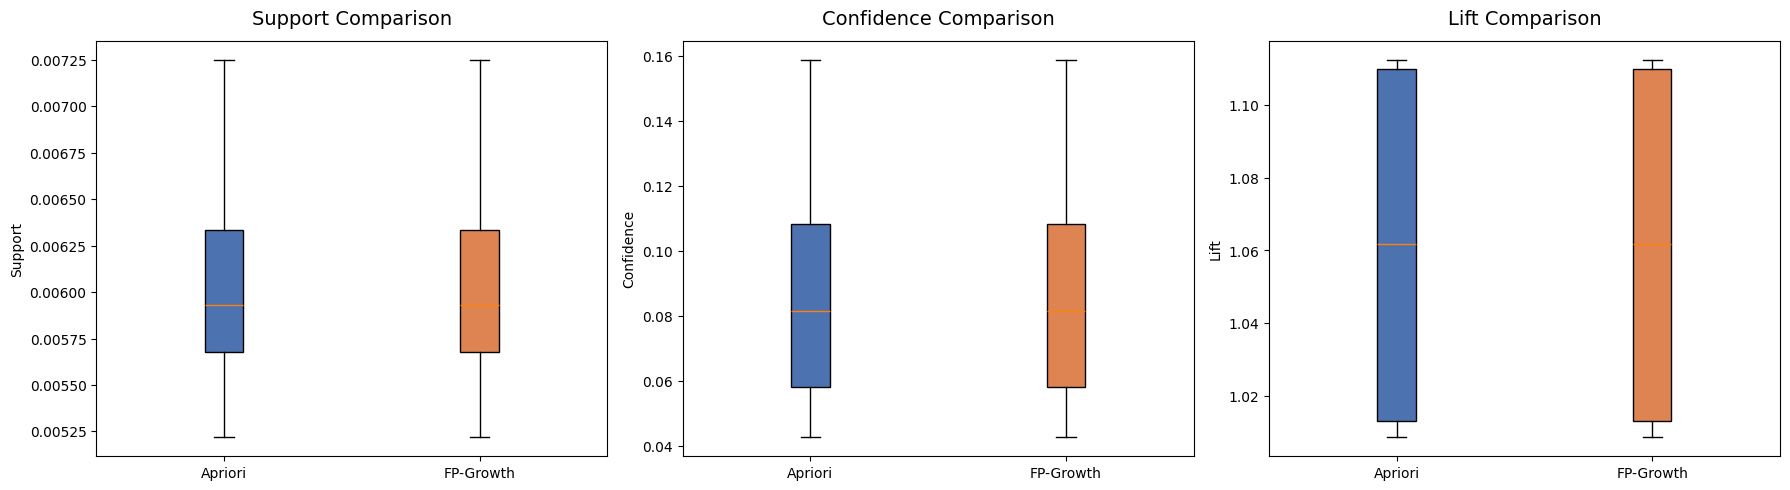

In [6]:
cls_comparison.plot_metrics_comparison()

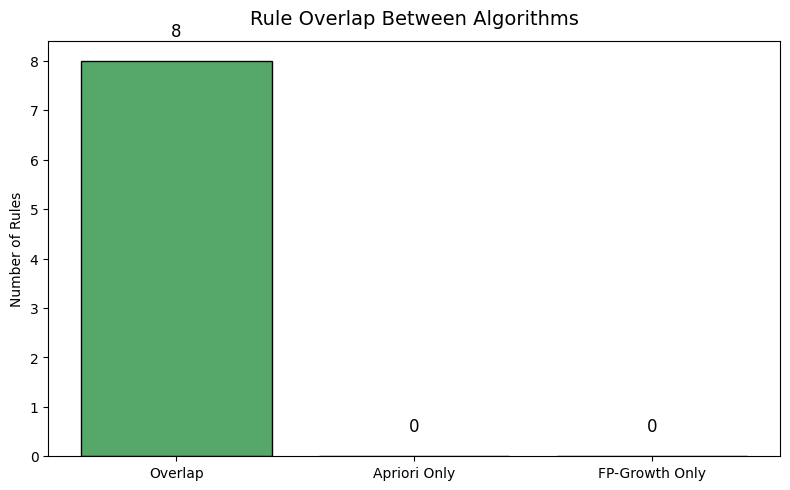

Rule overlap: 8 / 8 (100.0%)


In [7]:
cls_comparison.plot_rule_overlap()

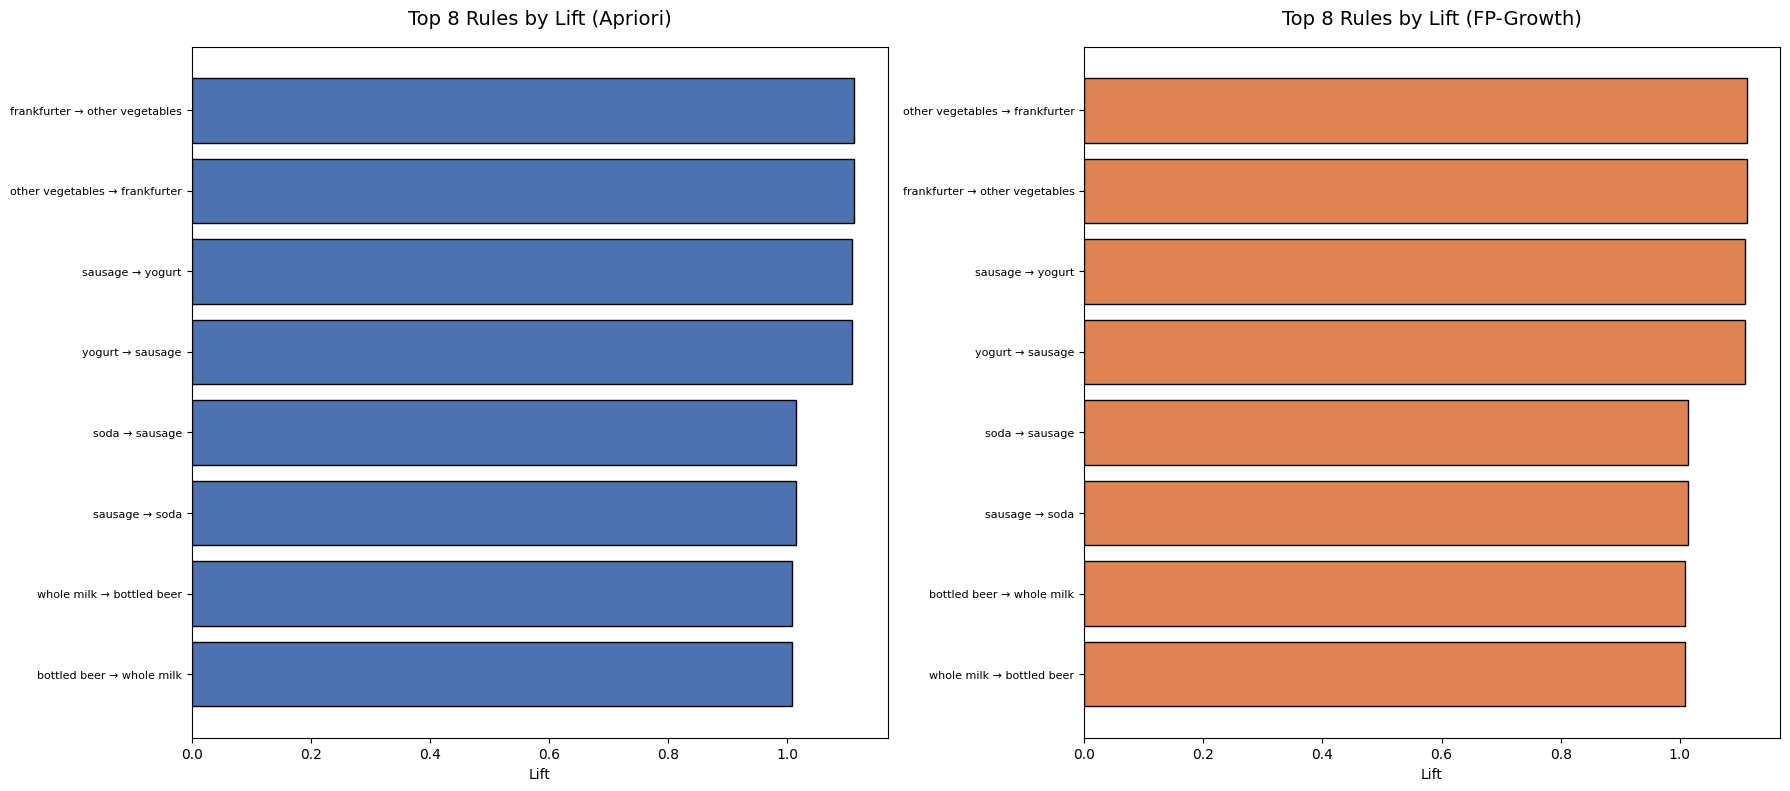

In [8]:
cls_comparison.plot_top_rules_comparison()

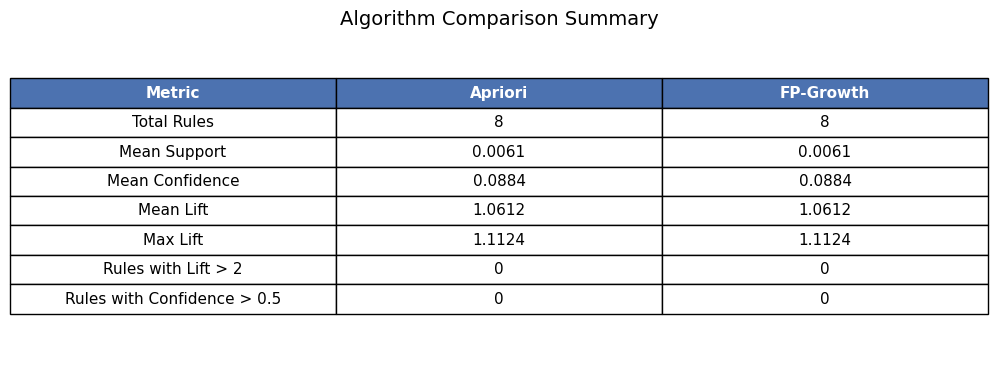

In [9]:
cls_comparison.plot_summary_table()

In [10]:
cls_comparison.print_comparison()


=== ALGORITHM COMPARISON ===
Metric                              Apriori    FP-Growth
-------------------------------------------------------
Total Rules                               8            8
Mean Support                         0.0061       0.0061
Max Support                          0.0073       0.0073
Mean Confidence                      0.0884       0.0884
Max Confidence                       0.1588       0.1588
Mean Lift                            1.0612       1.0612
Max Lift                             1.1124       1.1124


## Completion

In [11]:
print('\n=== COMPARISON COMPLETE ===')
print(f'Visualizations saved to: {str_dirname_output}')


=== COMPARISON COMPLETE ===
Visualizations saved to: ./output
